In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from data_process import TchouTchouData
from Model import TchoutchouModel

In [2]:
Data = TchouTchouData(
    r"C:\Users\Elfamoso\OneDrive\Bureau\Veille\Portfolio\Tchoutchou\Planning.xlsx"
)
df = Data.arrivals

In [3]:
print(df.head())

   Numero         Arrival       Departure Arrival_real Departure_real
0  881655 0 days 18:37:00 0 days 18:57:00        18:17          19:02
1  886580 0 days 18:38:00 0 days 18:58:00        18:18          19:03
2   17418 0 days 18:41:00 0 days 19:01:00        18:21          19:06
3  881079 0 days 18:47:00 0 days 19:07:00        18:27          19:12
4    6168 0 days 18:53:00 0 days 19:13:00        18:33          19:18


In [4]:
model=TchoutchouModel(df,nb_quai=14)

In [5]:
results=model.compare_optimizers()

Stopping search: maximum iterations reached --> 100
Stopping search: maximum iterations reached --> 100


In [ ]:
 #### Historique

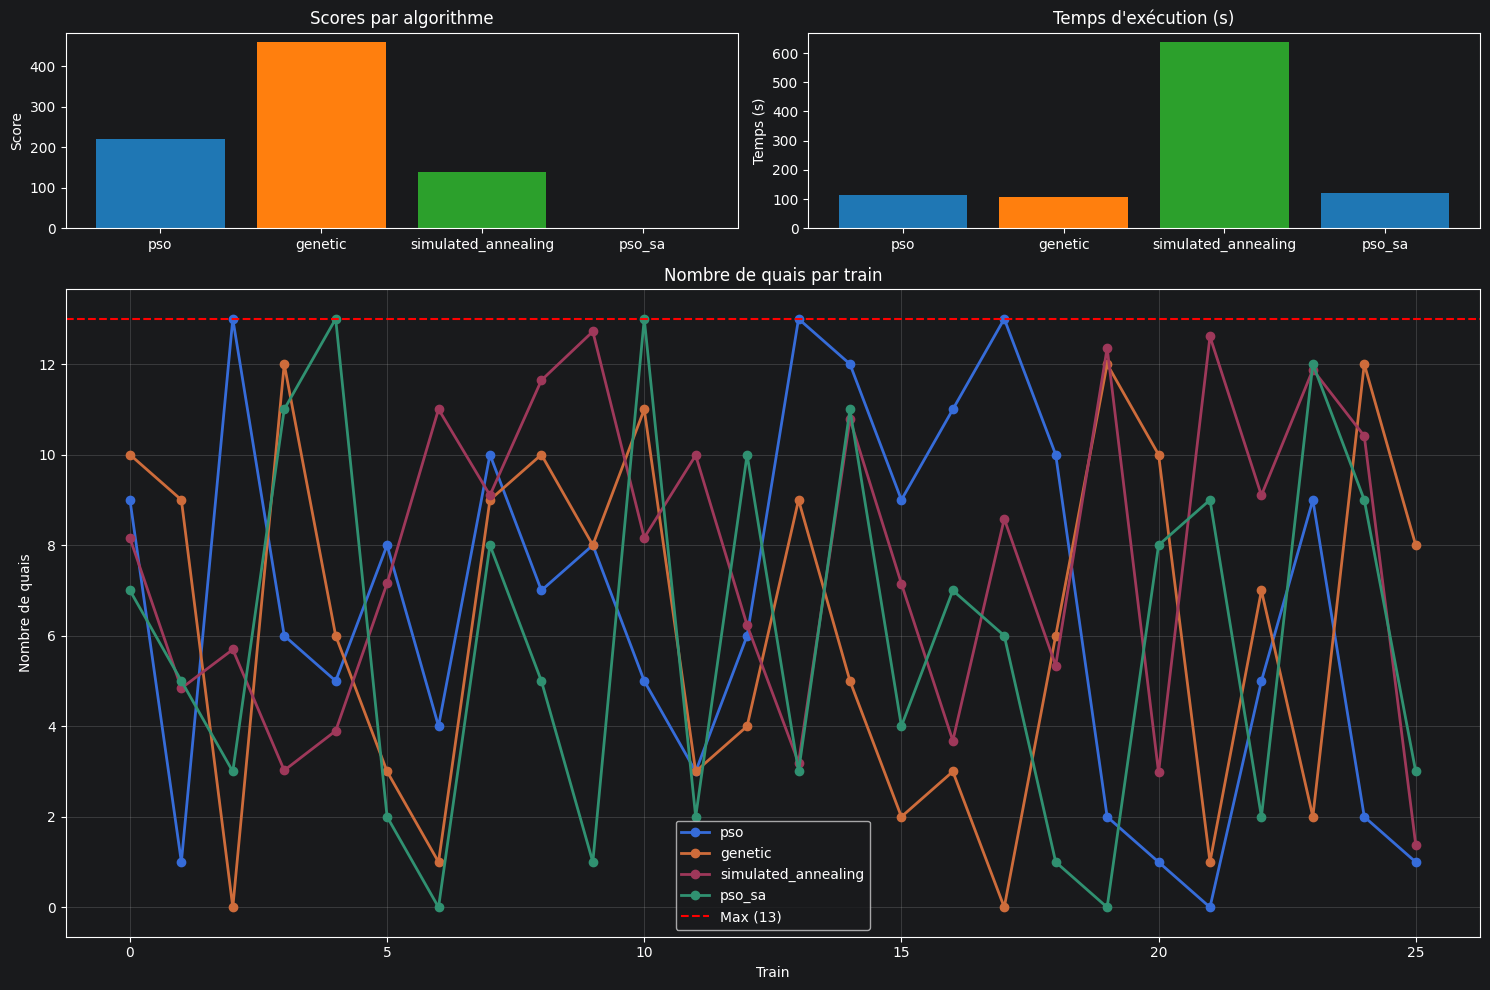

In [6]:
model.plot_summary(results)

In [11]:
    def plot_summary(results: dict):
        """Un seul graphique avec scores, temps et distribution des quais."""
        import matplotlib.gridspec as gridspec

        methods = list(results.keys())

        nb_quais=10

        fig = plt.figure(figsize=(15, 10))
        gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 2])

        # Scores
        ax1 = plt.subplot(gs[0, 0])
        scores = [results[m]['score'] for m in methods]
        ax1.bar(methods, scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        ax1.set_title("Scores par algorithme")
        ax1.set_ylabel("Score")

        # Temps
        ax2 = plt.subplot(gs[0, 1])
        times = [results[m]['time'] for m in methods]
        ax2.bar(methods, times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
        ax2.set_title("Temps d'exécution (s)")
        ax2.set_ylabel("Temps (s)")

        # Répartition par train
        ax3 = plt.subplot(gs[1:, :])
        for method in methods:
            ax3.plot(results[method]['N'], 'o-', label=method, linewidth=2, markersize=6)
        ax3.axhline(y=nb_quais - 1, color='red', linestyle='--', label=f"Max ({nb_quais - 1})")
        ax3.set_title("Nombre de quais par train")
        ax3.set_xlabel("Train")
        ax3.set_ylabel("Nombre de quais")
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

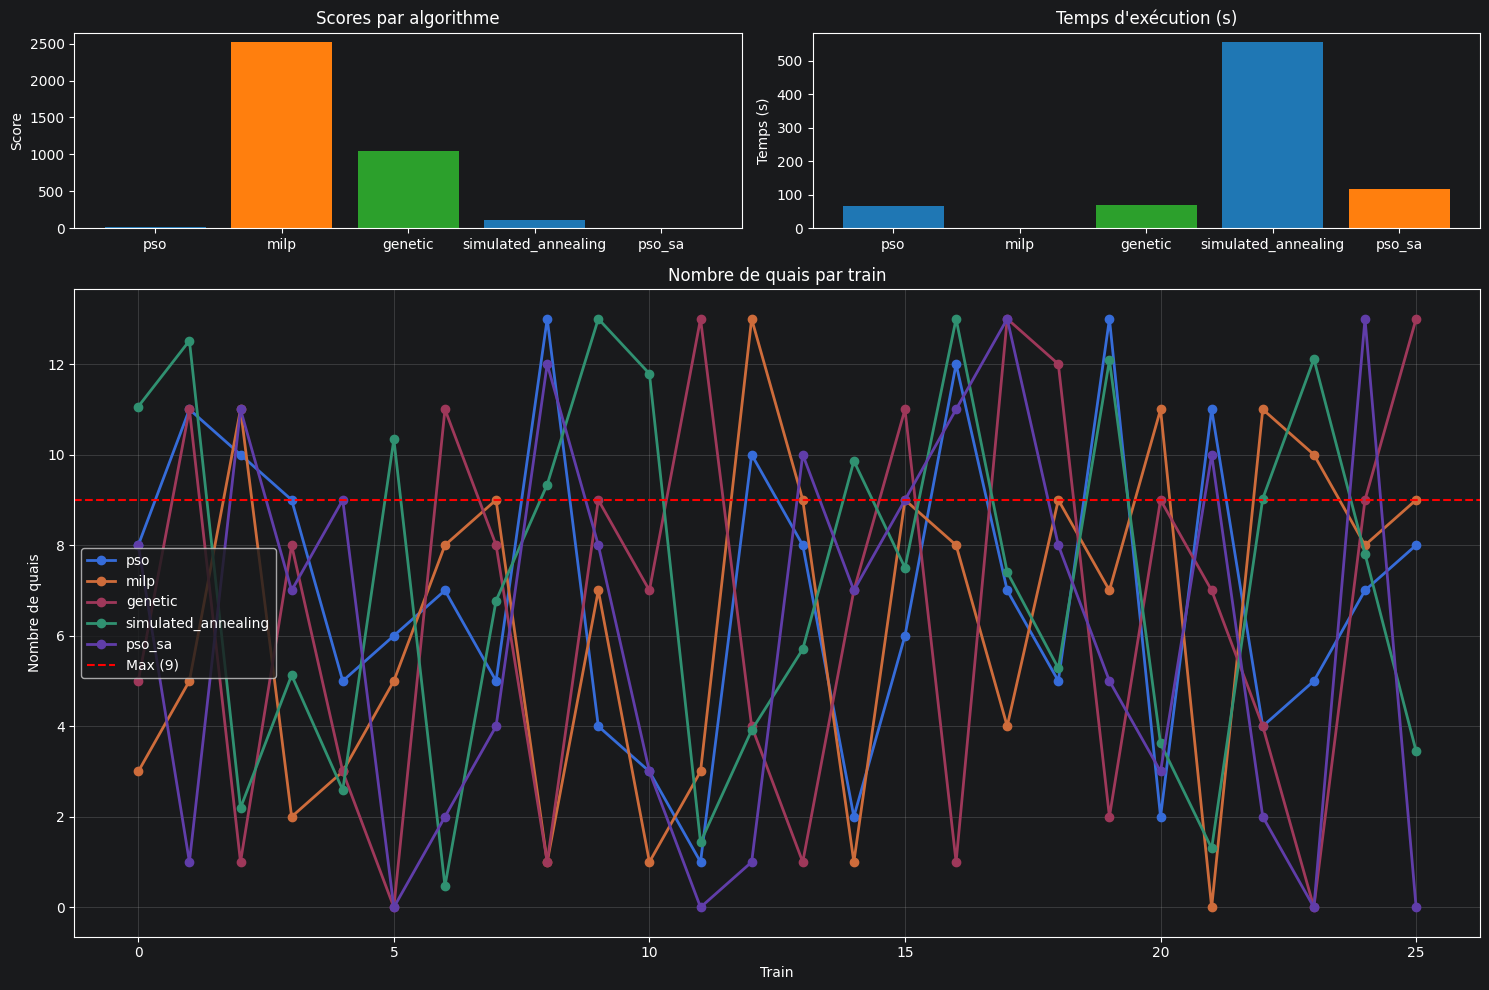

In [12]:
plot_summary(results)

In [7]:
##### Ca c le code à tester mais refacto

In [7]:
# ====================== IMPORTS ======================
import numpy as np
import pandas as pd
import time
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple, Union

# --- Pour CP-SAT (OR-Tools) ---
from ortools.sat.python import cp_model

# --- Pour PuLP ---
from pulp import LpProblem, LpVariable, LpMinimize, LpBinary, LpStatus, lpSum

# --- Pour Génétique (DEAP) ---
from deap import base, creator, tools, algorithms

# --- Pour PSO ---
try:
    from pyswarm import pso
except ImportError:
    print("⚠️ pyswarm non installé. Installe-le avec: pip install pyswarm")
    exit()

# ====================== CLASSE PRINCIPALE ======================
MINUTES_PER_DAY = 24 * 60

class TchoutchouModel:
    def __init__(self, df: pd.DataFrame, nb_quais: int, penalty: int = 10):
        self.df = df.sort_values(by=["Numero"], ascending=False)
        self.nb_quais = nb_quais
        self.nb_train = len(df)
        self.penalty = penalty
        self.train_schedule = self._build_train_schedule()

    def _build_train_schedule(self) -> Dict[int, Dict[str, Union[List[int], int]]]:
        """Construit un dictionnaire {num_train: {'arr': [h, m], 'dep': [h, m], 'emp': index}}."""
        schedule = {}
        for idx, row in self.df.iterrows():
            arrival = pd.to_datetime(row["Arrival_real"])
            departure = pd.to_datetime(row["Departure_real"])
            schedule[row["Numero"]] = {
                "arr": [arrival.hour, arrival.minute],
                "dep": [departure.hour, departure.minute],
                "emp": idx,
            }
        return schedule

    def generate_solution(self, quai_assignments: List[int]) -> List[List[np.ndarray]]:
        """Génère une matrice d'occupation à partir des affectations de quais."""
        solution = [
            [np.zeros(MINUTES_PER_DAY, dtype=int) for _ in range(self.nb_quais)]
            for _ in range(self.nb_train)
        ]
        for num, data in self.train_schedule.items():
            idx = data["emp"]
            quai = quai_assignments[idx]
            start = data["arr"][0] * 60 + data["arr"][1]
            end = data["dep"][0] * 60 + data["dep"][1]
            solution[idx][quai][start:end + 2] = 1  # +2 pour inclure `end`
        return solution

    def calculate_overlaps(self, solution: List[List[np.ndarray]]) -> float:
        """Calcule la somme des chevauchements entre trains (vectorisé)."""
        solution_array = np.array(solution)  # Shape: (nb_train, nb_quais, T)
        return np.sum([
            np.triu(solution_array[:, j, :] @ solution_array[:, j, :].T, k=1).sum()
            for j in range(self.nb_quais)
        ])

    def score(self, solution: List[List[np.ndarray]]) -> float:
        """Score = pénalité × chevauchements."""
        return self.calculate_overlaps(solution) * self.penalty

    def op_score(self, solution_matrix: List[List[np.ndarray]]) -> float:
        """Alias pour compatibilité avec ton code existant."""
        return self.score(solution_matrix)

    def op_solution(self, N: List[int]) -> List[List[np.ndarray]]:
        """Alias pour compatibilité avec ton code existant."""
        return self.generate_solution(N)

    # ====================== ALGORITHMES ======================
    def _run_genetic(self, pop_size=50, ngen=100, cx_prob=0.5, mut_prob=0.2) -> Tuple[List[int], float]:
        """Algorithme Génétique avec DEAP."""
        creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
        creator.create("Individual", list, fitness=creator.FitnessMin)
        toolbox = base.Toolbox()
        toolbox.register("attr_quai", np.random.randint, 0, self.nb_quais)
        toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_quai, n=self.nb_train)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)

        def evaluate(ind):
            return (self.op_score(self.op_solution(ind)),)

        toolbox.register("evaluate", evaluate)
        toolbox.register("mate", tools.cxUniform, indpb=0.5)
        toolbox.register("mutate", tools.mutUniformInt, low=0, up=self.nb_quais - 1, indpb=mut_prob)
        toolbox.register("select", tools.selTournament, tournsize=3)

        pop = toolbox.population(n=pop_size)
        hof = tools.HallOfFame(1)
        for _ in range(ngen):
            algorithms.varAnd(pop, toolbox, cxpb=cx_prob, mutpb=mut_prob)
            fits = toolbox.map(toolbox.evaluate, pop)
            for ind, fit in zip(pop, fits):
                ind.fitness.values = fit
            hof.update(pop)
        return hof[0], hof[0].fitness.values[0]

    def _run_cp_sat(self) -> Tuple[List[int], float]:
        """CP-SAT (OR-Tools) pour une solution optimale."""
        model = cp_model.CpModel()
        x = [model.NewIntVar(0, self.nb_quais - 1, f'x_{i}') for i in range(self.nb_train)]

        # Contrainte: pas de chevauchement sur un même quai
        for j in range(self.nb_quais):
            intervals = []
            for i in range(self.nb_train):
                deb = self.train_schedule[i]["arr"][0] * 60 + self.train_schedule[i]["arr"][1]
                fin = self.train_schedule[i]["dep"][0] * 60 + self.train_schedule[i]["dep"][1]
                interval = model.NewIntervalVar(deb, fin, False, f'interval_{i}_{j}')
                b = model.NewBoolVar(f'b_{i}_{j}')
                model.Add(x[i] == j).OnlyEnforceIf(b)
                model.Add(x[i] != j).OnlyEnforceIf(b.Not())
                intervals.append((interval, b))
            model.AddNoOverlap(intervals)

        model.Minimize(0)  # On cherche une solution faisable
        solver = cp_model.CpSolver()
        status = solver.Solve(model)

        if status in (cp_model.CpSolverStatus.OPTIMAL, cp_model.CpSolverStatus.FEASIBLE):
            solution = [solver.Value(x[i]) for i in range(self.nb_train)]
            return solution, float(self.op_score(self.op_solution(solution)))
        else:
            # Si pas de solution, retourner une solution aléatoire
            random_solution = np.random.randint(0, self.nb_quais, self.nb_train).tolist()
            return random_solution, float(self.op_score(self.op_solution(random_solution)))

    def _run_pulp(self) -> Tuple[List[int], float]:
        """PuLP (MILP) pour une solution optimale ou relaxée."""
        prob = LpProblem("Train_Quai_Assignment", LpMinimize)
        x = [[LpVariable(f'x_{i}_{j}', cat=LpBinary) for j in range(self.nb_quais)] for i in range(self.nb_train)]

        # Contrainte: chaque train est assigné à exactement un quai
        for i in range(self.nb_train):
            prob += lpSum(x[i][j] for j in range(self.nb_quais)) == 1

        # Pré-calculer les chevauchements entre paires de trains
        overlap = [[0] * self.nb_train for _ in range(self.nb_train)]
        for i in range(self.nb_train):
            for k in range(self.nb_train):
                if i >= k:
                    continue
                deb_i = self.train_schedule[i]["arr"][0] * 60 + self.train_schedule[i]["arr"][1]
                fin_i = self.train_schedule[i]["dep"][0] * 60 + self.train_schedule[i]["dep"][1]
                deb_k = self.train_schedule[k]["arr"][0] * 60 + self.train_schedule[k]["arr"][1]
                fin_k = self.train_schedule[k]["dep"][0] * 60 + self.train_schedule[k]["dep"][1]
                overlap[i][k] = max(0, min(fin_i, fin_k) - max(deb_i, deb_k))

        # Variable auxiliaire pour les chevauchements
        w = {}
        total_overlap = 0
        for j in range(self.nb_quais):
            for i in range(self.nb_train):
                for k in range(i + 1, self.nb_train):
                    if overlap[i][k] > 0:
                        w[i, k, j] = LpVariable(f'w_{i}_{k}_{j}', cat=LpBinary)
                        prob += w[i, k, j] >= x[i][j] + x[k][j] - 1
                        prob += w[i, k, j] <= x[i][j]
                        prob += w[i, k, j] <= x[k][j]
                        total_overlap += overlap[i][k] * w[i, k, j]

        prob += total_overlap
        prob.solve()

        if LpStatus[prob.status] in ('Optimal', 'Feasible'):
            solution = []
            for i in range(self.nb_train):
                for j in range(self.nb_quais):
                    if x[i][j].varValue == 1:
                        solution.append(j)
                        break
            return solution, float(self.op_score(self.op_solution(solution)))
        else:
            random_solution = np.random.randint(0, self.nb_quais, self.nb_train).tolist()
            return random_solution, float(self.op_score(self.op_solution(random_solution)))

    def _generate_neighbor(self, solution: List[int]) -> List[int]:
        """Génère un voisin pour SA (swap, move ou reverse)."""
        neighbor = solution.copy()
        move_type = random.choice(['swap', 'move', 'reverse'])
        if move_type == 'swap':
            i, j = random.sample(range(len(neighbor)), 2)
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
        elif move_type == 'move':
            i = random.randint(0, len(neighbor) - 1)
            neighbor[i] = random.randint(0, self.nb_quais - 1)
        elif move_type == 'reverse':
            i, j = sorted(random.sample(range(len(neighbor)), 2))
            neighbor[i:j+1] = neighbor[i:j+1][::-1]
        return neighbor

    def _run_pso_sa(self, n_particles=50, max_iter=100, sa_niter=500, cooling_rate=0.99) -> Tuple[List[int], float]:
        """Hybride PSO + Recuit Simulé (discret)."""
        # Étape 1: PSO pour l'exploration
        def pso_objective(x):
            N = np.clip(np.round(x), 0, self.nb_quais - 1).astype(int).tolist()
            return self.op_score(self.op_solution(N))

        lb, ub = np.zeros(self.nb_train), np.full(self.nb_train, self.nb_quais - 1)
        best_x, _ = pso(pso_objective, lb, ub, swarmsize=n_particles, maxiter=max_iter)
        pso_N = np.clip(np.round(best_x), 0, self.nb_quais - 1).astype(int).tolist()
        pso_score = self.op_score(self.op_solution(pso_N))

        # Étape 2: Recuit Simulé pour l'exploitation locale
        current_solution = pso_N.copy()
        current_score = pso_score
        best_solution, best_score = current_solution, current_score
        temp = 1.0

        for _ in range(sa_niter):
            new_solution = self._generate_neighbor(current_solution)
            new_score = self.op_score(self.op_solution(new_solution))
            delta = new_score - current_score
            if delta < 0 or random.random() < math.exp(-delta / temp):
                current_solution, current_score = new_solution, new_score
                if current_score < best_score:
                    best_solution, best_score = current_solution, current_score
            temp *= cooling_rate
        return best_solution, float(best_score)

    # ====================== COMPARAISON ======================
    def compare_all(self, n_runs=5, verbose=True) -> Dict[str, List[Dict]]:
        """Compare les 4 algorithmes sur n_runs exécutions."""
        results = {
            'genetic': [],
            'cp_sat': [],
            'pulp': [],
            'pso_sa': []
        }

        for _ in range(n_runs):
            for method in results:
                start = time.time()
                if method == 'genetic':
                    N, score = self._run_genetic(pop_size=50, ngen=100)
#                elif method == 'cp_sat':
#                    N, score = self._run_cp_sat()
                elif method == 'pulp':
                    N, score = self._run_pulp()
                elif method == 'pso_sa':
                    N, score = self._run_pso_sa(n_particles=50, max_iter=100, sa_niter=500)
                elapsed = time.time() - start
                results[method].append({
                    'N': N,
                    'score': score,
                    'time': elapsed
                })
                if verbose:
                    print(f"{method.upper():<8} | Run {_+1}/{n_runs} | Score: {score:.2f} | Temps: {elapsed:.3f}s")

        if verbose:
            print("\n=== RÉSULTATS MOYENS ===")
            for method, runs in results.items():
                scores = [r['score'] for r in runs]
                times = [r['time'] for r in runs]
                print(f"{method.upper():<8} | Score: {np.mean(scores):.2f} ± {np.std(scores):.2f} | Temps: {np.mean(times):.3f}s ± {np.std(times):.3f}s")

        return results

    # ====================== VISUALISATION ======================
    def plot_all_results(self, results: Dict[str, List[Dict]]):
        """Génère 6 graphiques pour analyser les performances."""
        methods = list(results.keys())
        fig = plt.figure(figsize=(20, 15))
        gs = fig.add_gridspec(3, 3)

        # 1. Boxplot des scores
        ax1 = fig.add_subplot(gs[0, 0])
        scores_data = []
        for m in methods:
            scores_data.extend([r['score'] for r in results[m]])
        sns.boxplot(x=[m for m in methods for _ in range(len(results[m]))],
                    y=scores_data, ax=ax1, palette="Set2")
        ax1.set_title("📊 Distribution des scores par algorithme", fontsize=12)
        ax1.set_ylabel("Score (chevauchements × pénalité)")
        ax1.tick_params(axis='x', rotation=45)

        # 2. Temps moyen par algorithme
        ax2 = fig.add_subplot(gs[0, 1])
        times_mean = [np.mean([r['time'] for r in results[m]]) for m in methods]
        times_std = [np.std([r['time'] for r in results[m]]) for m in methods]
        ax2.bar(methods, times_mean, yerr=times_std, capsize=5, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
        ax2.set_title("⏱️ Temps d'exécution moyen (s)", fontsize=12)
        ax2.set_ylabel("Temps (s)")
        ax2.grid(True, alpha=0.3)

        # 3. Heatmap des affectations (1er run)
        ax3 = fig.add_subplot(gs[0, 2])
        first_solutions = [results[m][0]['N'] for m in methods]
        heatmap_data = np.zeros((self.nb_quais, self.nb_train))
        for sol in first_solutions:
            for train_idx, quai in enumerate(sol):
                heatmap_data[quai][train_idx] += 1
        sns.heatmap(heatmap_data, ax=ax3, cmap="YlGnBu", xticklabels=10, yticklabels=True)
        ax3.set_title("🔥 Heatmap des affectations (1er run)", fontsize=12)
        ax3.set_xlabel("Train")
        ax3.set_ylabel("Quai")

        # 4. Quai assigné par train (tous les runs)
        ax4 = fig.add_subplot(gs[1, :])
        for m in methods:
            for run in results[m]:
                ax4.plot(run['N'], 'o-', label=f"{m} (run {results[m].index(run)+1})", linewidth=1, markersize=3, alpha=0.7)
        ax4.axhline(y=self.nb_quais-1, color='red', linestyle='--', alpha=0.5, label=f"Max ({self.nb_quais-1})")
        ax4.set_title("📈 Quai assigné par train (tous les runs)", fontsize=12)
        ax4.set_xlabel("Train")
        ax4.set_ylabel("Quai")
        ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax4.grid(True, alpha=0.3)

        # 5. Histogramme des scores
        ax5 = fig.add_subplot(gs[2, 0])
        for m in methods:
            ax5.hist([r['score'] for r in results[m]], alpha=0.5, label=m, bins=10)
        ax5.set_title("📉 Histogramme des scores", fontsize=12)
        ax5.set_xlabel("Score")
        ax5.set_ylabel("Fréquence")
        ax5.legend()

        # 6. Temps vs Score (scatter)
        ax6 = fig.add_subplot(gs[2, 1])
        for m in methods:
            times = [r['time'] for r in results[m]]
            scores = [r['score'] for r in results[m]]
            ax6.scatter(times, scores, label=m, alpha=0.6, s=50)
        ax6.set_title("⚡ Temps vs Score", fontsize=12)
        ax6.set_xlabel("Temps (s)")
        ax6.set_ylabel("Score")
        ax6.legend()
        ax6.grid(True, alpha=0.3)

        # 7. Boîte à moustaches pour le temps
        ax7 = fig.add_subplot(gs[2, 2])
        times_data = []
        for m in methods:
            times_data.extend([r['time'] for r in results[m]])
        sns.boxplot(x=[m for m in methods for _ in range(len(results[m]))],
                    y=times_data, ax=ax7, palette="Set2")
        ax7.set_title("⏳ Distribution des temps par algorithme", fontsize=12)
        ax7.set_ylabel("Temps (s)")
        ax7.tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

# ====================== GÉNÉRATION DE DONNÉES TEST ======================
def generate_test_data(nb_train=20, nb_quais=5, seed=42):
    """Génère un DataFrame de test avec des trains aléatoires."""
    np.random.seed(seed)
    data = {
        "Numero": list(range(nb_train)),
        "Arrival_real": pd.date_range("2026-06-23", periods=nb_train, freq="30min"),
        "Departure_real": pd.date_range("2026-06-23", periods=nb_train, freq="30min") + pd.Timedelta(minutes=20)
    }
    df = pd.DataFrame(data)
    # Ajouter du randomness pour créer des chevauchements
    df["Arrival_real"] = df["Arrival_real"] + pd.to_timedelta(np.random.randint(0, 120, nb_train), unit='min')
    df["Departure_real"] = df["Arrival_real"] + pd.Timedelta(minutes=np.random.randint(10, 90, nb_train))
    return df

# ====================== EXÉCUTION ======================
if __name__ == "__main__":
    # Paramètres
    NB_TRAINS = 20  # Augmente pour tester la scalabilité
    NB_QUAIS = 5
    PENALTY = 10


    # Initialiser le modèle
    model = TchoutchouModel(df, nb_quais=NB_QUAIS, penalty=PENALTY)

    # Comparer les algorithmes
    results = model.compare_all(n_runs=5, verbose=True)

    # Visualiser les résultats
    model.plot_all_results(results)

C:\Users\Elfamoso\AppData\Local\Programs\Python\Python314\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\Elfamoso\AppData\Local\Programs\Python\Python314\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


GENETIC  | Run 1/5 | Score: 3590.00 | Temps: 19.121s
CP_SAT   | Run 1/5 | Score: 3590.00 | Temps: 0.000s


KeyError: 0